In [51]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata_new.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
nmask

51

Text(0, 0.5, 'U')

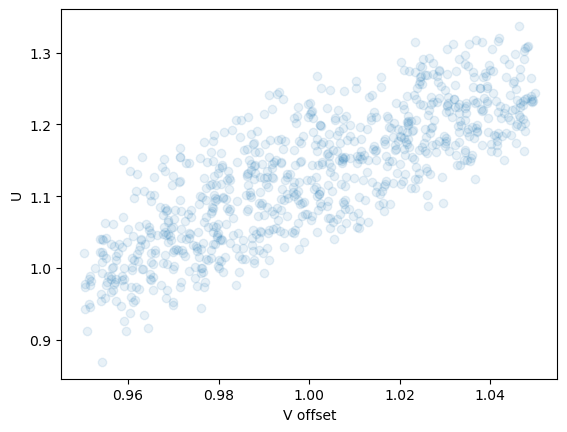

In [12]:
plt.scatter(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

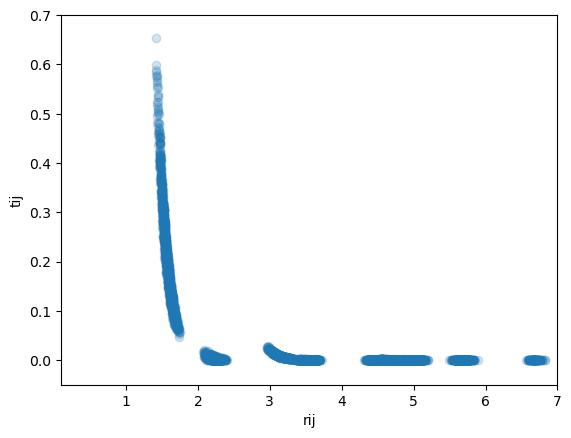

In [13]:
plt.scatter(dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

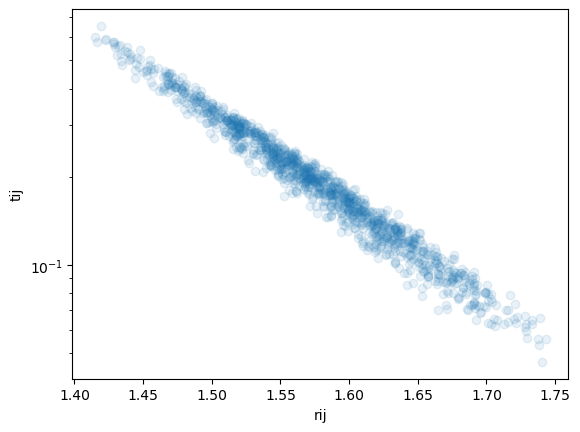

In [37]:
plt.scatter(nnr[mask].flatten(), nnt[mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

`wf_cost` is the final cost function values in Wannierization. `total_cost_func` is the variance sum of the Hubbard parameters.

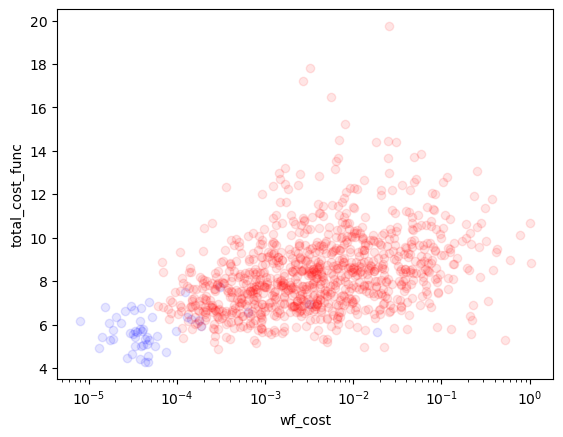

In [33]:
plt.scatter(
    dat["wf_cost"][mask].flatten(),
    dat["total_cost_func"][mask].flatten(),
    color="b",
    alpha=0.1,
)
plt.scatter(
    dat["wf_cost"][~mask].flatten(),
    dat["total_cost_func"][~mask].flatten(),
    color="r",
    alpha=0.1,
)
plt.xlabel("wf_cost")
plt.ylabel("total_cost_func")
plt.xscale("log")

### Correlation to geometric factors

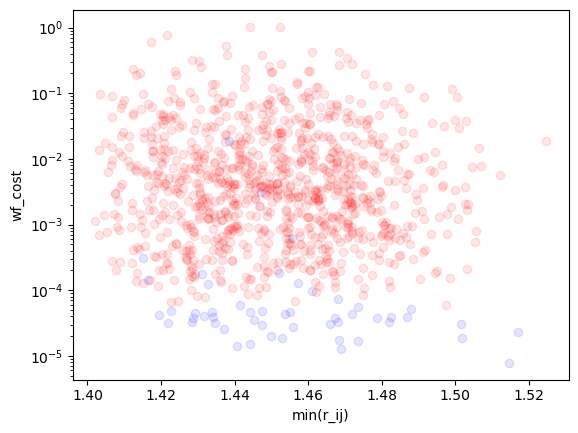

In [40]:
# rmin = dat["rij"] + np.eye(N) * 100
# rmin = np.min(rmin, axis=(1, 2))
rmin = np.min(nnr, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("min(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

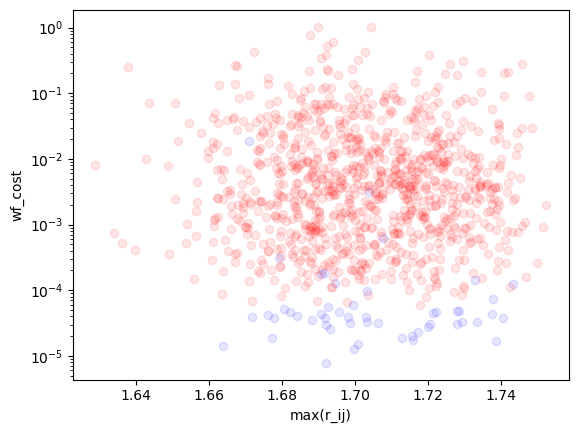

In [41]:
# rmin = dat["rij"]
# rmin = np.max(rmin, axis=(1, 2))
rmin = np.max(nnr, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("max(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

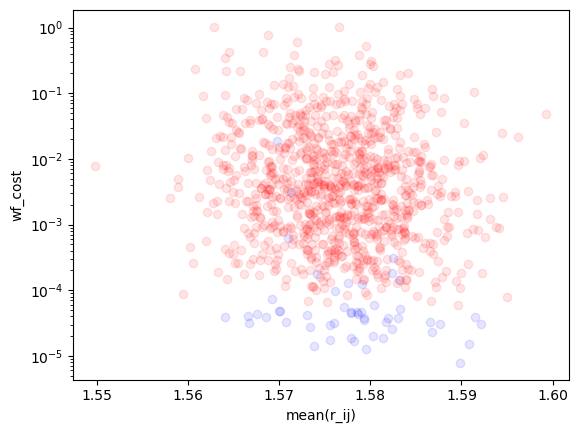

In [42]:
# rmin = dat["rij"]
# rmin = np.mean(rmin, axis=(1, 2))
rmin = np.mean(nnr, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("mean(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

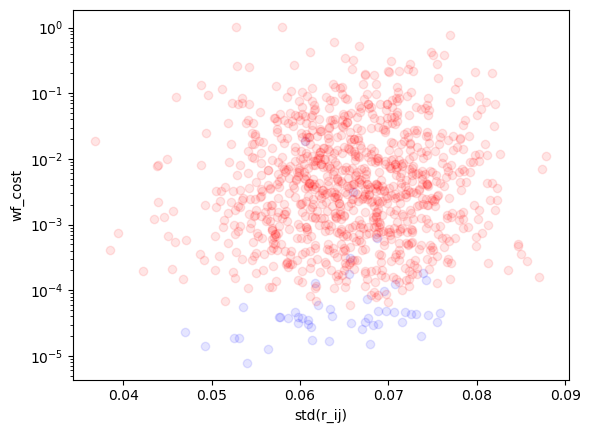

In [43]:
# rmin = dat["rij"]
# rmin = np.mean(rmin, axis=(1, 2))
rmin = np.std(nnr, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("std(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

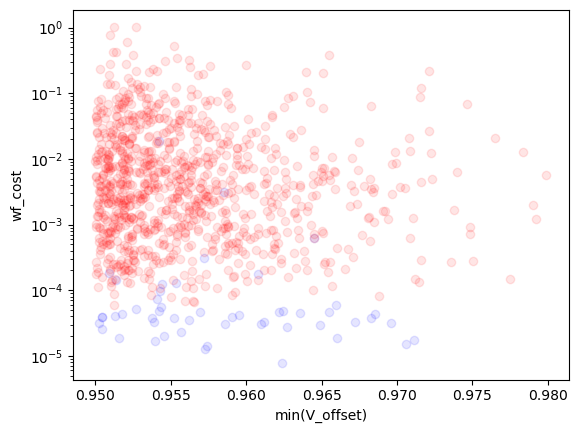

In [44]:
rmin = dat["V_offset"]
rmin = np.min(rmin, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("min(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

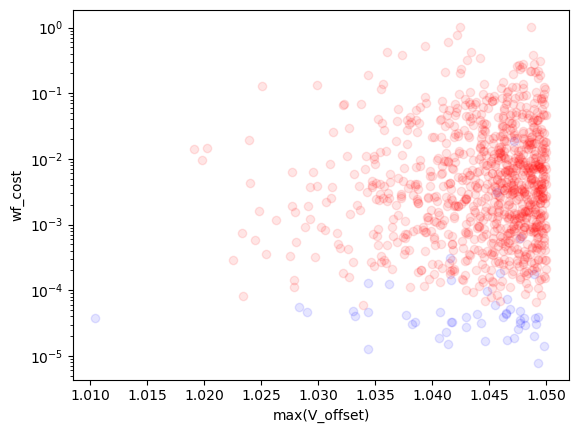

In [45]:
rmin = dat["V_offset"]
rmin = np.max(rmin, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("max(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

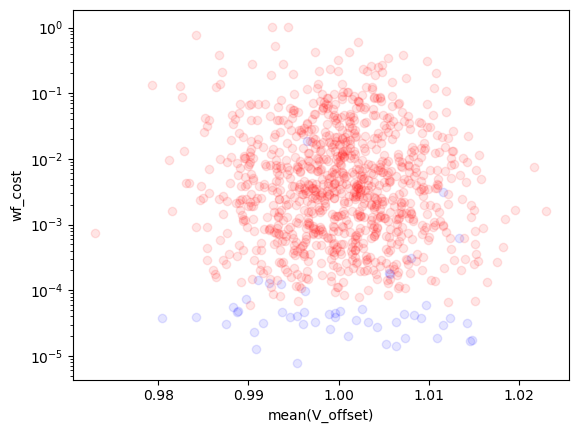

In [46]:
rmin = dat["V_offset"]
rmin = np.mean(rmin, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("mean(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

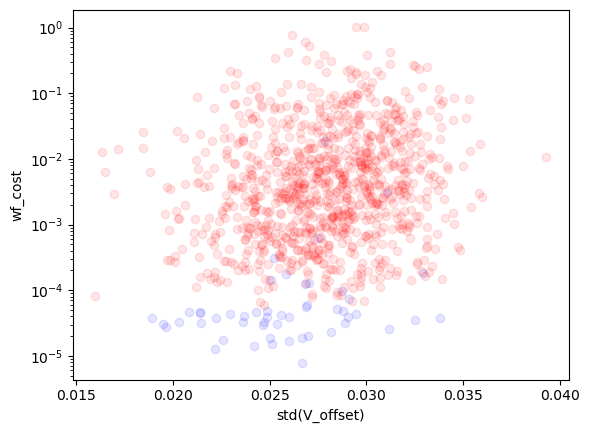

In [47]:
rmin = dat["V_offset"]
rmin = np.std(rmin, axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("std(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

Wannierization failure doesn't seem to be clearly relevant to any single geometric factor.

What if I pile `wf_cost` and compare it with all `rij`?

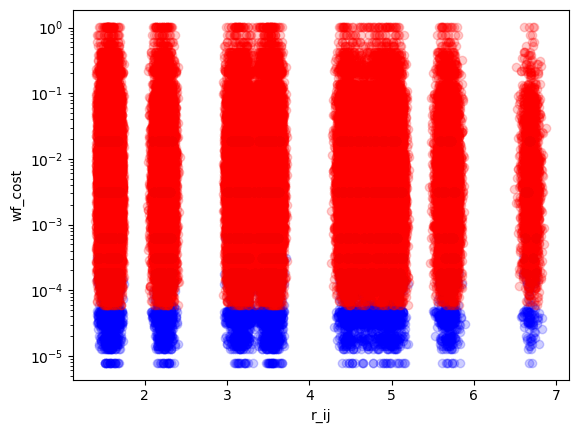

In [52]:
rmin = dat["rij"]
# Creating a mask that excludes the diagonal
offdiag = np.ones((N, N), dtype=bool)
np.fill_diagonal(offdiag, 0)

# Flattening the array
rmin = rmin.reshape(rmin.shape[0], -1)[:, offdiag.ravel()]
wfc = np.tile(dat["wf_cost"], (N**2 - N, 1)).T

plt.scatter(rmin[mask].flatten(), wfc[mask].flatten(), color="b", alpha=0.1)
plt.scatter(rmin[~mask].flatten(), wfc[~mask].flatten(), color="r", alpha=0.1)
plt.xlabel("r_ij")
plt.ylabel("wf_cost")
plt.yscale("log")

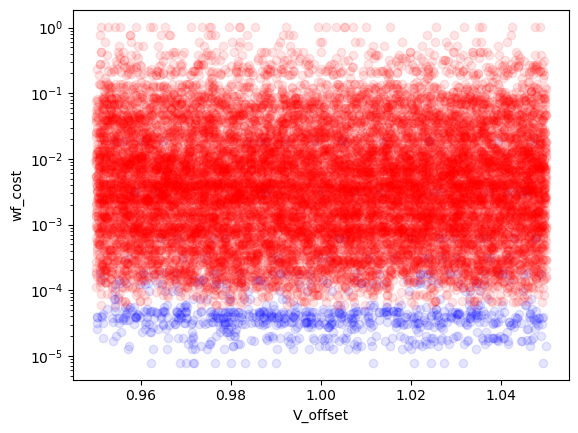

In [53]:
rmin = dat["V_offset"]
wfc = np.tile(dat["wf_cost"], (N, 1)).T

plt.scatter(rmin[mask].flatten(), wfc[mask].flatten(), color="b", alpha=0.1)
plt.scatter(rmin[~mask].flatten(), wfc[~mask].flatten(), color="r", alpha=0.1)
plt.xlabel("V_offset")
plt.ylabel("wf_cost")
plt.yscale("log")

No clear distinction on how geometric factors are distributed with higer or lower wf_cost.

### Correlation to Hubbard parameters

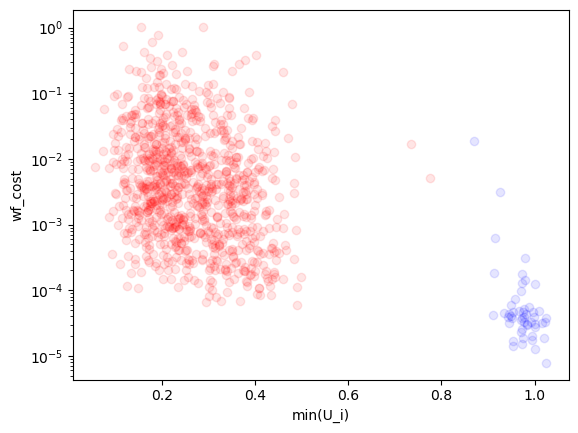

In [54]:
rmin = np.min(dat["U_i"], axis=1)

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("min(U_i)")
plt.ylabel("wf_cost")
plt.yscale("log")

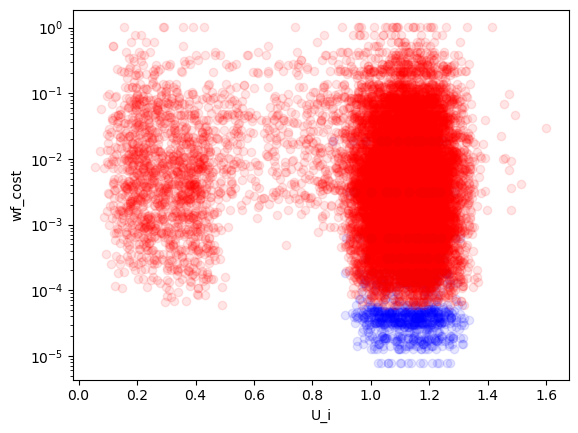

In [55]:
rmin = dat["U_i"]
wfc = np.tile(dat["wf_cost"], (N, 1)).T

plt.scatter(rmin[mask].flatten(), wfc[mask].flatten(), color="b", alpha=0.1)
plt.scatter(rmin[~mask].flatten(), wfc[~mask].flatten(), color="r", alpha=0.1)
plt.xlabel("U_i")
plt.ylabel("wf_cost")
plt.yscale("log")

The key difference between successful and failed Wannierization is min(U_i).

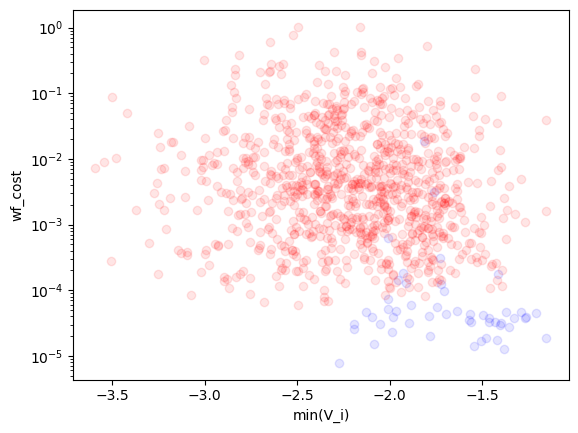

In [57]:
tij = dat["t_ij"]
rmin = np.min(tij, axis=(1, 2))

plt.scatter(rmin[mask], dat["wf_cost"][mask], color="b", alpha=0.1)
plt.scatter(rmin[~mask], dat["wf_cost"][~mask], color="r", alpha=0.1)
plt.xlabel("min(V_i)")
plt.ylabel("wf_cost")
plt.yscale("log")

Wannierization failure can be seen much easilier from the Hubbard parameter anomalies.

Success samples are too few that the clusters cannot be well identified.

TODO:
1. Reduce variation by 2x ~ 5x, e.g. 2% ~ 1%
2. Check if fix one parameter the correlation is clearer
3. Do PBC

#### Check what is special about success samples

The success sample with largest `wf_cost`:

In [14]:
np.argmax(dat["wf_cost"][mask])

38

In [9]:
dat["V_offset"][mask][38]

array([0.98789334, 1.0393441 , 0.95633002, 1.02372939, 1.02426605,
       0.96042826, 0.96501628, 1.00522672, 0.99879464, 1.00468324,
       0.95422374, 1.04714533, 1.01368658, 0.99211486, 0.98399546,
       0.98675026])

In [11]:
dat["wf_cost"][mask][38]

0.01860337895326478

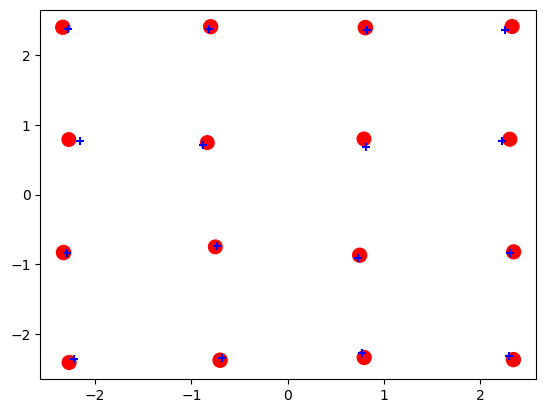

In [29]:
id = 38
plt.scatter(
    dat["trap_centers"][mask][id, :, 0],
    dat["trap_centers"][mask][id, :, 1],
    c="r",
    s=dat["V_offset"][mask][id] * 100,
    marker="o",
)
plt.scatter(
    dat["wf_centers"][mask][id, :, 0],
    dat["wf_centers"][mask][id, :, 1],
    c="b",
    marker="+",
)

In the above case, the success sample has `wf_cost~0.01` which is much larger than other failed cases.

The failed case with the smallest `wf_cost`:

In [12]:
np.argmin(dat["wf_cost"][~mask])

685

In [18]:
dat["wf_cost"][~mask][685]

6.0375199566081776e-05

In [17]:
dat["U_i"][~mask][685]

array([1.18640423, 1.0467714 , 1.15364073, 1.14114337, 1.05316769,
       1.31764841, 0.97020731, 1.08426489, 1.14935689, 1.0851945 ,
       0.48928711, 1.17881975, 1.27006013, 1.07602622, 1.1593513 ,
       1.1201145 ])

In [19]:
dat["V_offset"][~mask][685]

array([0.98199412, 0.95442957, 1.00366683, 0.97663734, 0.95692111,
       1.03389558, 0.95124563, 0.97673767, 1.00518353, 0.9925593 ,
       1.00369867, 1.02458719, 1.02053478, 0.97348807, 1.00982346,
       0.97807413])

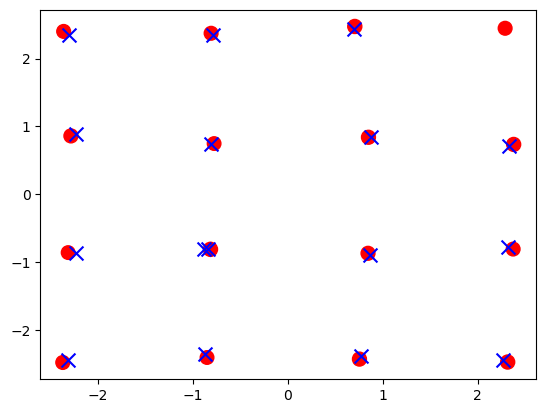

In [28]:
id = 685
plt.scatter(
    dat["trap_centers"][~mask][id, :, 0],
    dat["trap_centers"][~mask][id, :, 1],
    c="r",
    s=dat["V_offset"][~mask][id] * 100,
    marker="o",
)
plt.scatter(
    dat["wf_centers"][~mask][id, :, 0],
    dat["wf_centers"][~mask][id, :, 1],
    s=100,
    c="b",
    marker="x",
)

Similar conclusion holds.

So `wf_cost` is not a good indicator of success, rather `min(U_ij)` is.